# Сети в графах

1. В Интернете узлы сети (машины) имеют множество взаимных связей, то есть для заданной пары узлов может существовать множество путей между ними. Общая пропускная способность (bandwidth) между двумя заданными узлами рассчитывается как максимальный объем данных, который может быть передан от одного узла к другому в единицу времени. Используя технику под названием packet switching, эти данные могут быть переданы одновременно по нескольким путям. 

    Например, на рисунке показана сеть с четырьмя узлами и пятью связями. Каждая связь имеет пропускную в единицу времени (указаны на связях).

    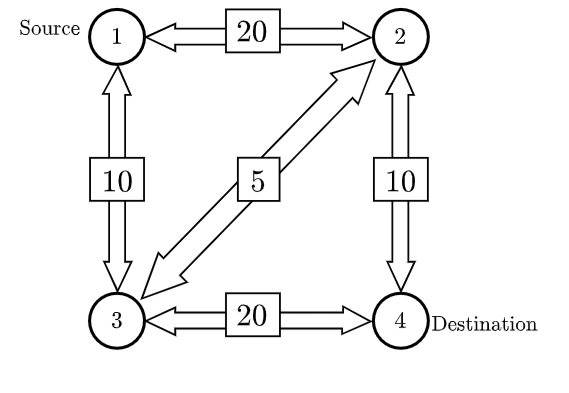

    В нашем примере пропускная способность между узлом 1 и узлом 4 равна 25 (сумма пропускных способностей для путей 1-2-4 (bandwidth = 10), 1-3-4  (bandwidth = 10), и 1-2-3-4  (bandwidth = 5).

    Никакая другая комбинация путей между узлами 1 и 4 не обеспечивает большей пропускной способности.

    Задача: напишите программу, которая вычисляет пропускную способность между двумя заданными узлами в сети с учетом индивидуальных пропускных способностей всех соединений в сети. Считайте, что в этой задаче
    пропускная способность соединения всегда одинакова в обоих направлениях (что не обязательно верно в
    реальном мире).

    Вход содержит описания нескольких сетей. Каждое описание начинается со строки, содержащей
    одно целое число n (2 ≤ n ≤ 100), обозначающее количество узлов в сети. Узлы пронумерованы
    от 1 до n. В следующей строке записаны три числа _s_, _t_ и _c_. Числа _s_ и _t_ являются стартовыми и конечными узлами связей, а число _c_ — общее количество связей в сети. Далее идут _c_ строк, описывающих связи. Каждая из этих строк содержит три целых числа: первые два — номера подключенных узлов, а третье число — пропускная способность (неотрицательное число, не превышающее 1000).
    Между парой узлов может быть более одного соединения, но узел не может быть соединен с собой. Все соединения являются двунаправленными, но суммарный объем данных, передаваемый в обоих направлениях, должен быть не больше
    пропускной способности.
    Строка «0» завершает ввод.

    Пример ввода:

    4 \
    1 4 5 \
    1 2 20 \
    1 3 10 \
    2 3 5 \
    2 4 10 \
    3 4 20 \
    0

    Пример вывода:

    Network 1 \
    The bandwidth is 25.

In [3]:
from collections import deque


def edmonds_karp(graph, source, sink):
    n = len(graph)
    residual_graph = [row[:] for row in graph]
    max_flow = 0

    while True:
        # Поиск кратчайшего пути с помощью BFS
        parent = [-1] * n
        queue = deque([source])
        parent[source] = source

        while queue:
            u = queue.popleft()
            for v, cap in enumerate(residual_graph[u]):
                if parent[v] == -1 and cap > 0:
                    parent[v] = u
                    queue.append(v)
                    if v == sink:
                        break
            else:
                continue
            break
        else:
            # Если не дошли до стока, значит путей больше нет
            break

        # Находим "узкое горлышко" в найденном BFS-пути
        path_flow = float("Inf")
        s = sink
        while s != source:
            path_flow = min(path_flow, residual_graph[parent[s]][s])
            s = parent[s]

        # Обновляем остаточную сеть
        max_flow += path_flow
        v = sink
        while v != source:
            u = parent[v]
            residual_graph[u][v] -= path_flow
            residual_graph[v][u] += path_flow
            v = parent[v]

    return max_flow


nom = 1
while True:
    n = int(input())
    if n == 0:
        break
    s, t, c = map(int, input().split())
    cap = [[0] * n for _ in range(n)]
    for _ in range(c):
        u, v, w = map(int, input().split())
        u -= 1
        v -= 1
        cap[u][v] += w
        cap[v][u] += w
    maxflow = edmonds_karp(cap, s - 1, t - 1)
    print(f"Network {nom}")
    print(f"The bandwidth is {maxflow}.")
    nom += 1


 4
 1 4 5
 1 2 20
 1 3 10
 2 3 5
 2 4 10
 3 4 20


Network 1
The bandwidth is 25.


 0


2. Вася находится на острове Скряг. Он хочет домой. Но чтобы получить билет на пароход до дома ему нужно сыграть в игру. Задача игры состоит в следующем: нужно собрать N карт с номерами от 1 до N (порядок карт не имеет значения). У Васи уже есть N карт, но они не образуют последовательность от 1 до N. Поэтому он хочет, чтобы Вы ему помогли. Некоторые карты он может менять на другие, заплатив за это некоторым количеством монет. Помогите Васе получить билет, совершив минимальное количество обменов.

    Вход

    Первая строка содержит t — количество тестов (1<=t<=10). Для каждого тестового примера:

    - в первой строке указано количество карт N (2<=N<=500)
    - следующие N строк содержат N карт, принадлежащих Васе
    - далее строка содержит e — количество различных разрешенных типов обмена.

    Следующие e строк содержат по два целых числа $x_i,y_i,$ каждое из которых означает, что мы можем обменять карту с номером $x$ на карту с номером $y$ и наоборот.
    После каждого тестового примера есть пустая строка.

    Выход

    Для каждого тестового примера выведите строку, обозначающую минимальное требуемое количество обменов.

    Пример ввода:

    1 \
    4 \
    1 \
    2 \
    2 \
    2 \
    2 \
    2 3 \
    3 4

    Пример вывода:

    3

In [1]:
import heapq

inf = 10 ** 10


class Edge:
    def __init__(self, to, rev, cap, cost):
        self.to = to
        self.rev = rev
        self.cap = cap
        self.cost = cost


def add_edge(graph, fr, to, cap, cost):
    graph[fr].append(Edge(to, len(graph[to]), cap, cost))
    graph[to].append(Edge(fr, len(graph[fr]) - 1, 0, -cost))


for _ in range(int(input())):
    n = int(input())
    cnt = [0] * (n + 1)
    for _ in range(n):
        card = int(input())
        cnt[card] += 1
    e = int(input())
    swaps = []
    for _ in range(e):
        x, y = map(int, input().split())
        swaps.append((x, y))
    V = n + 2
    s = 0
    t = n + 1
    graph = [[] for _ in range(V)]
    maxf = 0
    for i in range(1, n + 1):
        if cnt[i] > 1:
            add_edge(graph, s, i, cnt[i] - 1, 0)
            maxf += cnt[i] - 1
        elif cnt[i] == 0:
            add_edge(graph, i, t, 1, 0)
    for x, y in swaps:
        add_edge(graph, x, y, inf, 1)
        add_edge(graph, y, x, inf, 1)
    n = len(graph)
    prevv = [0] * n
    preve = [0] * n
    h = [0] * n
    res = 0
    flow = 0
    while flow < maxf:
        dist = [inf] * n
        dist[s] = 0
        pq = [(0, s)]
        while pq:
            d, v = heapq.heappop(pq)
            if dist[v] < d:
                continue
            for i, e in enumerate(graph[v]):
                if e.cap > 0 and dist[e.to] > dist[v] + e.cost + h[v] - h[e.to]:
                    dist[e.to] = dist[v] + e.cost + h[v] - h[e.to]
                    prevv[e.to], preve[e.to] = v, i
                    heapq.heappush(pq, (dist[e.to], e.to))
        if dist[t] == inf:
            break
        for v in range(n):
            if dist[v] < inf:
                h[v] += dist[v]
        d = maxf - flow
        v = t
        while v != s:
            d = min(d, graph[prevv[v]][preve[v]].cap)
            v = prevv[v]
        flow += d
        res += d * h[t]
        v = t
        while v != s:
            e = graph[prevv[v]][preve[v]]
            e.cap -= d
            graph[v][e.rev].cap += d
            v = prevv[v]
    print(res)

 1
 4
 1
 2
 2
 2
 2
 2 3
 3 4


3
